In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.shape)
print(test_df.shape)

(7352, 563)
(2947, 563)


In [3]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
train_df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [5]:
train_df.isnull().sum().sum()

np.int64(0)

In [6]:
duplicates = train_df.duplicated().sum()
print(duplicates)

0


In [7]:
train_df.drop_duplicates(inplace=True)

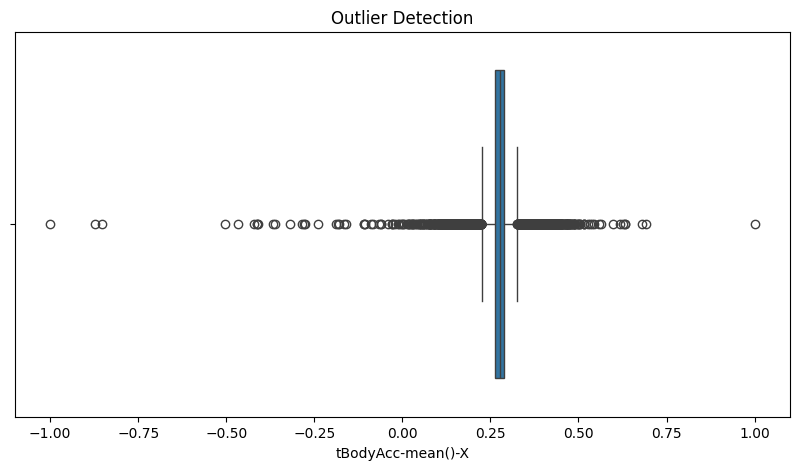

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train_df['tBodyAcc-mean()-X'])
plt.title('Outlier Detection')
plt.show()

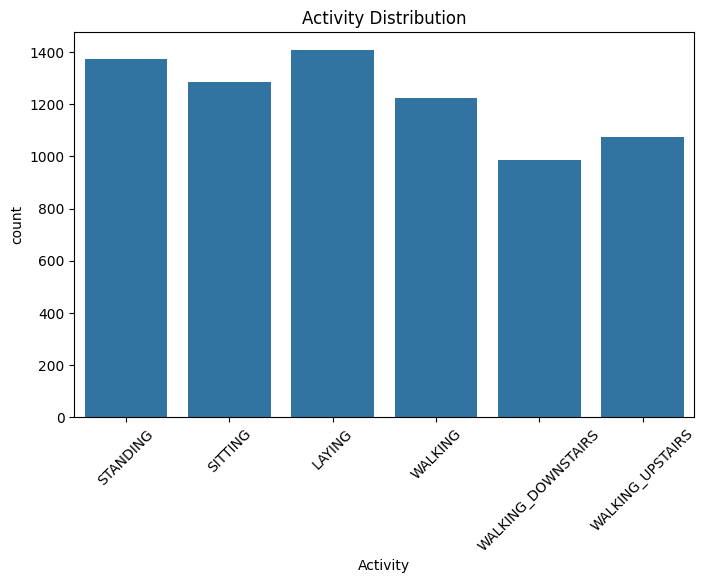

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x='Activity')
plt.xticks(rotation=45)
plt.title('Activity Distribution')
plt.show()

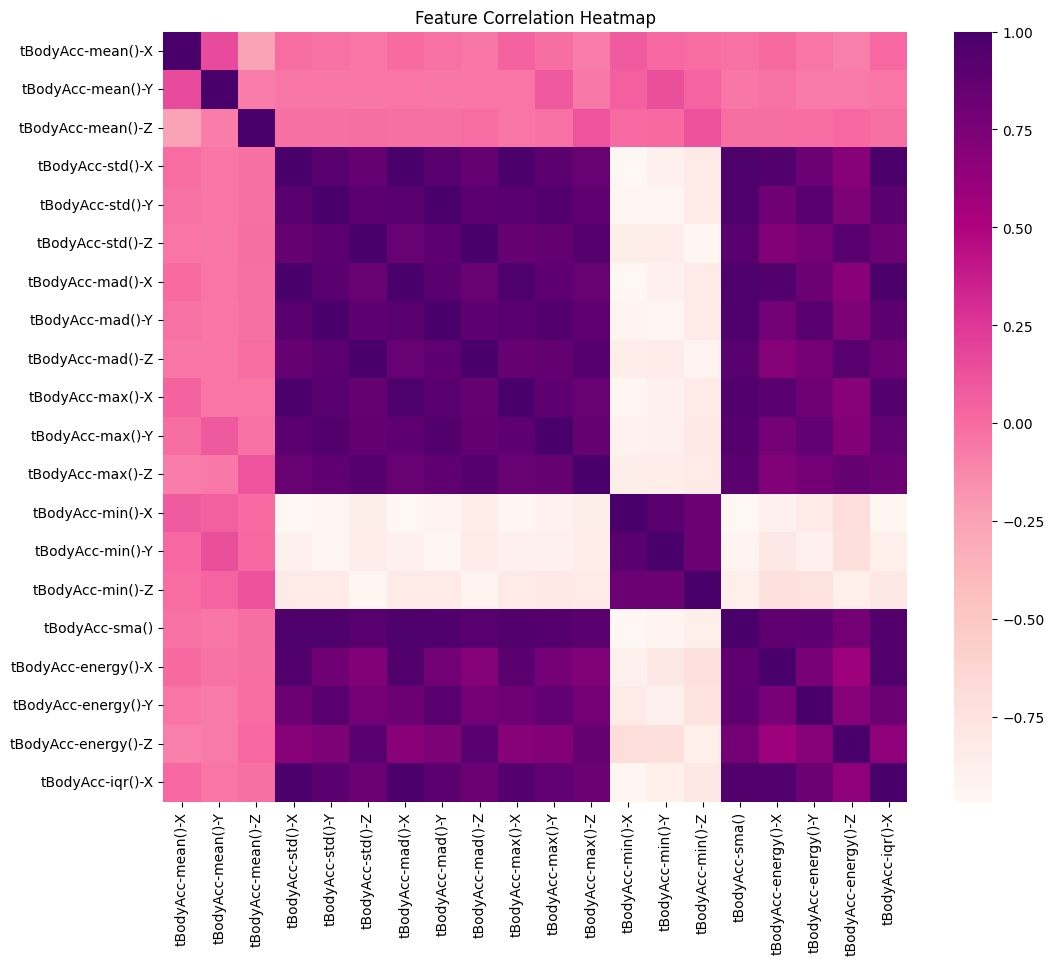

In [10]:
subset = train_df.iloc[:, :20]

plt.figure(figsize=(12,10))
sns.heatmap(subset.corr(), cmap='RdPu')
plt.title('Feature Correlation Heatmap')
plt.show()

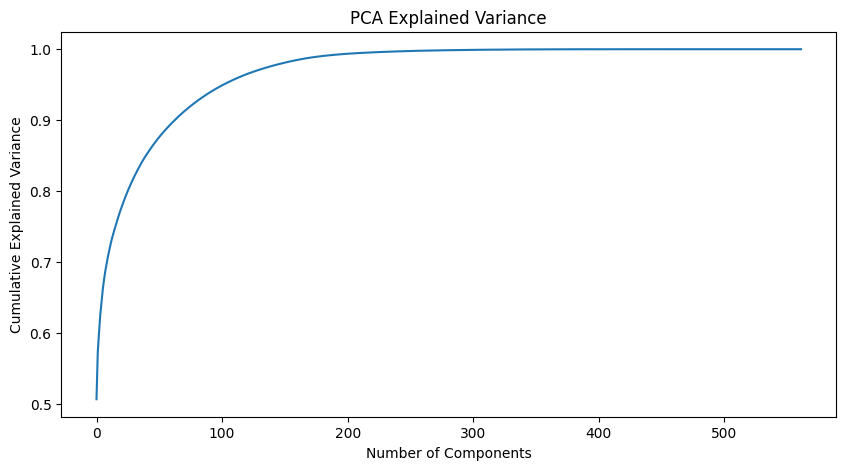

In [11]:
X_train = train_df.drop(['Activity'], axis=1)
y_train = train_df['Activity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

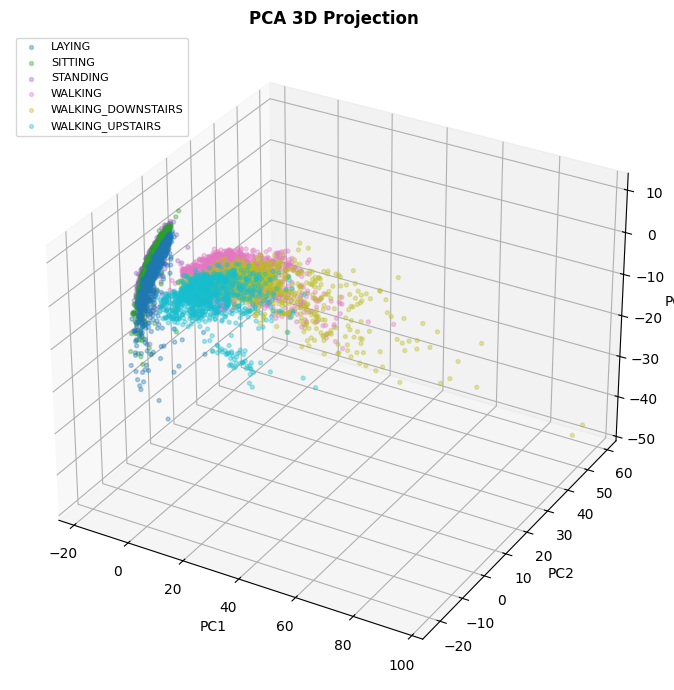

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_scaled)

activities = np.unique(y_train)
colors = plt.cm.tab10(np.linspace(0, 1, len(activities)))
ACTIVITY_COLORS = dict(zip(activities, colors))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for act, color in ACTIVITY_COLORS.items():
    mask = (y_train.values == act)
    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        c=[color],
        alpha=0.35,
        s=8,
        label=act
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D Projection', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

In [14]:
X_train = train_df.drop('Activity', axis=1)
y_train = train_df['Activity']

X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']

In [15]:
pca = PCA(n_components=0.95)

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC())
])

In [17]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [18]:
print(grid_search.best_params_)

{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [19]:
{
    'svm__C': 10,
    'svm__gamma': 'scale',
    'svm__kernel': 'rbf'
}

{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

In [20]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9219545300305395


In [22]:
print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.93      0.85      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.92      0.96      0.94       496
WALKING_DOWNSTAIRS       0.91      0.89      0.90       420
  WALKING_UPSTAIRS       0.90      0.87      0.89       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



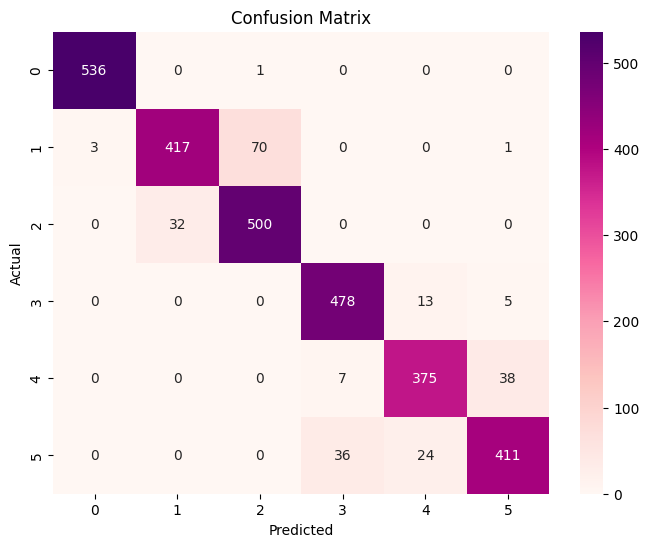

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu') 
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
import joblib

joblib.dump(best_model, 'svm_har_model.pkl')

['svm_har_model.pkl']


# Human Activity Recognition using SVM

## Project Overview
This project focuses on classifying human activities using smartphone sensor data and Support Vector Machine (SVM).

### Dataset Information
- The dataset contains more than 10,000 records and more than 20 features.
- Features are extracted from smartphone motion sensors.
- Target column: `Activity`

### Workflow
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Train/Test Split Verification
5. Feature Scaling
6. Dimensionality Reduction using PCA
7. SVM Model Training
8. Hyperparameter Tuning
9. Model Evaluation
10. Model Saving



## Train/Test Split Validation

The dataset already provides predefined training and testing files (`train.csv` and `test.csv`).

This prevents data leakage and ensures proper model generalization.



## Outlier Handling Note

Outliers were visualized using boxplots.

Since SVM performs better after feature scaling, StandardScaler was applied before training. Extreme outlier removal was avoided to preserve data integrity and avoid unnecessary data loss.



## PCA Explanation

Principal Component Analysis (PCA) was used for dimensionality reduction.

PCA helps:
- Reduce feature dimensionality
- Improve training efficiency
- Preserve most important variance in the dataset


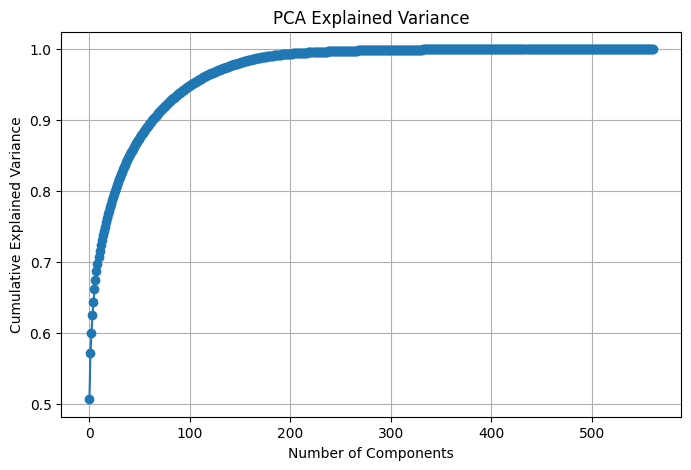

Variance retained by first 50 components: 0.8742


In [27]:
# PCA Variance Check
pca_temp = PCA().fit(X_scaled)

explained_variance = np.cumsum(pca_temp.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

print(f"Variance retained by first 50 components: {explained_variance[49]:.4f}")


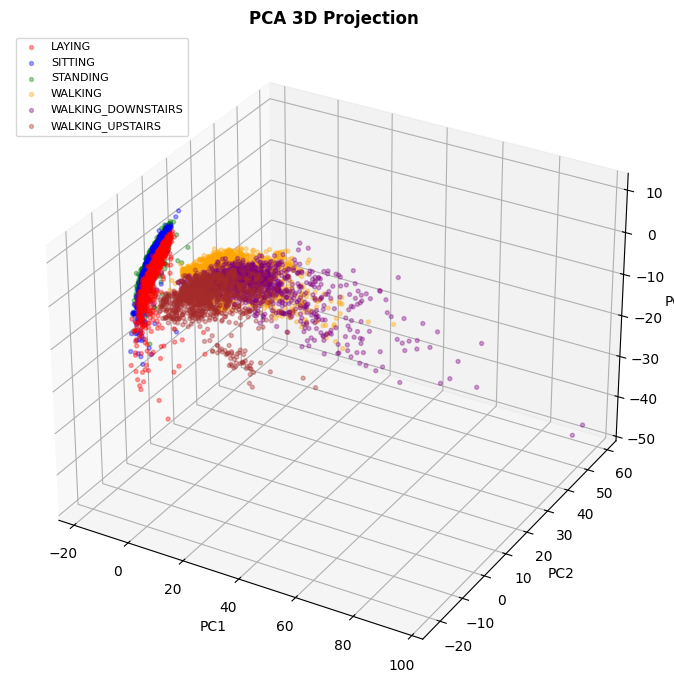

In [28]:
from mpl_toolkits.mplot3d import Axes3D

# Define activity colors
unique_activities = np.unique(y_train)

colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

ACTIVITY_COLORS = {
    act: colors[i % len(colors)]
    for i, act in enumerate(unique_activities)
}

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# PCA transformation
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_train_scaled)

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for act, color in ACTIVITY_COLORS.items():

    mask = (y_train.values == act)

    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        c=[color],
        alpha=0.35,
        s=8,
        label=act
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title('PCA 3D Projection', fontweight='bold')

ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()



# Final Conclusion

- Data preprocessing and scaling improved model performance.
- PCA successfully reduced dimensionality while preserving important information.
- SVM achieved strong classification performance after hyperparameter tuning.
- The complete ML pipeline was implemented successfully.
